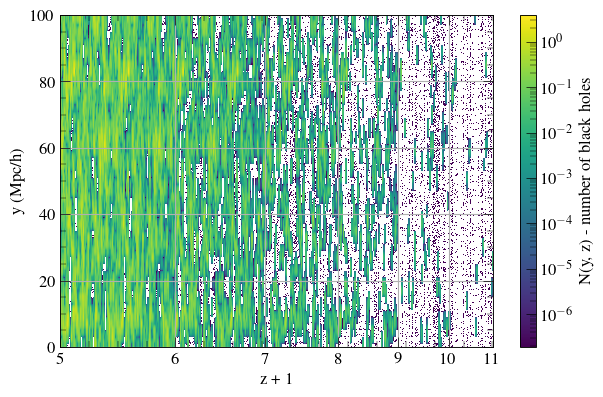

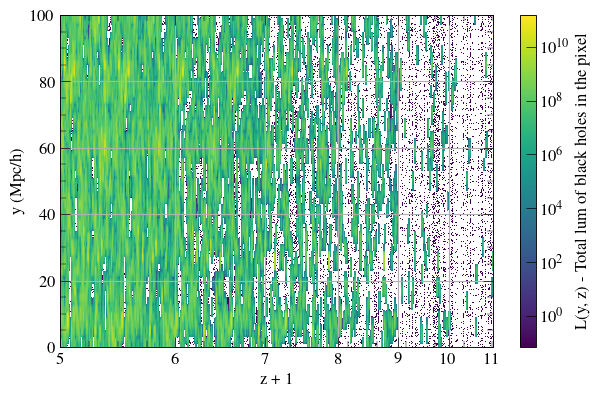

In [33]:
# 1) Load the 7 files which contains MBII black holes details in slices centered at 4, 5, 6, 7, 8, 9, 10 redshifts.
# 2) Extract the x, y, and z coordinates of the black holes.
# 3) Define the number of pixels in each dimension (50, 50, 1). and pixelated the data.
# 4) store each array which is n(x,y) for each redshift in a list called nz_arrays.


import numpy as np
import matplotlib.pyplot as plt
# Import interp1d
from scipy.interpolate import interp1d
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM


# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

file_paths = ['/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_034.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_029.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_026.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_024.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_020.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_019.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_018.txt']

nz_arrays = []
Lz_arrays = []

# defining the luminosity bin
min_lum = 0
max_lum = np.infty

for file_path in file_paths:
    # Load the data from the file
    data = np.loadtxt(file_path)
    
    # Extract the x, y, and z coordinates
    x_coordinates = data[:, 1]
    y_coordinates = data[:, 2]
    z_coordinates = data[:, 3]
    bh_lum = data[:, 8]

    # I want to introduce luminosity cuts at this point
    bh_lum_sol = bh_lum * 1.472 * 10 ** 12 # 1 M0/yr * 0.1 * c^2 equvialent to 1.472 x 10^12 L0

    # now get the indices of the black holes that are within the luminosity range
    ind_lum = np.where((bh_lum_sol >= min_lum) & (bh_lum_sol < max_lum))[0]

    x_coordinates = x_coordinates[ind_lum]
    y_coordinates = y_coordinates[ind_lum]
    z_coordinates = z_coordinates[ind_lum]   
    
    # Define the number of pixels in each dimension
    num_pixels_x = 50
    num_pixels_y = 50
    num_pixels_z = 50
    
    # Calculate the pixel size in each dimension
    x_range = (0, 100000) #(np.min(x_coordinates), np.max(x_coordinates))
    y_range = (0, 100000) #(np.min(y_coordinates), np.max(y_coordinates))
    z_range = (0, 100000) #(np.min(z_coordinates), np.max(z_coordinates))
    
    pixel_size_x = (x_range[1] - x_range[0]) / num_pixels_x
    pixel_size_y = (y_range[1] - y_range[0]) / num_pixels_y
    pixel_size_z = (z_range[1] - z_range[0]) / num_pixels_z
    
    # Calculate the pixel indices for each coordinate
    pixel_indices_x = ((x_coordinates - x_range[0]) / pixel_size_x).astype(int)
    pixel_indices_y = ((y_coordinates - y_range[0]) / pixel_size_y).astype(int)
    pixel_indices_z = ((z_coordinates - z_range[0]) / pixel_size_z).astype(int)
    
    # Create an empty n(x, y, z) array
    n_array = np.zeros((num_pixels_x, num_pixels_y, num_pixels_z))
    L_array = np.zeros((num_pixels_x, num_pixels_y, num_pixels_z))
    
    # Count the number of particles in each pixel
    for i in range(len(x_coordinates)):
        n_array[pixel_indices_x[i], pixel_indices_y[i], pixel_indices_z[i]] += 1
        L_array[pixel_indices_x[i], pixel_indices_y[i], pixel_indices_z[i]] += bh_lum_sol[i]
    
    nz_arrays.append(n_array)
    Lz_arrays.append(L_array)


# Now each array in nz_arrays contains the n(x, y, z) for each redshift slice centered at 4, 5, 6, 7, 8, 9, 10.

# First convert the redshifts to comoving distances
# Define the redshifts
redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

# Calculate the comoving distances
new_z_axis = cosmo.comoving_distance(redshifts).value * h  # Convert to h^-1 Mpc

# These are the slice centers in the z direction for each redshift slice.

# Now I want to interpolate the data in nz_arrays to get the n(x, y, z) for any comoving distance in the range of new_z_axis.
sim_evolv_linear = interp1d(new_z_axis, nz_arrays, axis=0)
lum_sim_evolv_linear = interp1d(new_z_axis, Lz_arrays, axis=0)

# Calculate the pixel size in each dimension in Mpch^-1
x_range = (0, 100) #(np.min(x_coordinates), np.max(x_coordinates))
y_range = (0, 100) #(np.min(y_coordinates), np.max(y_coordinates))
z_range = (0, 100) #(np.min(z_coordinates), np.max(z_coordinates))

pixel_size_x = (x_range[1] - x_range[0]) / num_pixels_x
pixel_size_y = (y_range[1] - y_range[0]) / num_pixels_y
pixel_size_z = (z_range[1] - z_range[0]) / num_pixels_z

# Now I want to make another 3d array which contains the n(x, y, z) for each comoving distance in the range of new_z_axis.
# Define the new z axis which has the resolution of the simulation box.

new_z_axis = np.arange(new_z_axis[0], new_z_axis[-1], pixel_size_z)

# Create an empty 3d array with shape same as the simulation along x and y
# and the length of the new z axis.

Lightcone = np.zeros((num_pixels_x, num_pixels_y, len(new_z_axis)))
lum_Lightcone = np.zeros((num_pixels_x, num_pixels_y, len(new_z_axis)))

# Now we need to fill the Lightcone array with the data from sim_evolv_linear, where when we move 1 comoving distance in the 
# z direction of the Lightcone array, we move 1 comiving distance in direction chosen at the start in the sim_evolv_linear array.

# We need a function of the following nature:
# Inputs: a

# This funcition finds the started plane of the simulation box given a normal vector and a center point.

from scipy.ndimage import map_coordinates

def create_rotated_plane(normal_vector, plane_center, num_pixels_plane):
    """
    Extract a 2D plane from a 3D array that makes an arbitrary angle with the axes.
    
    Parameters:
    array_3d (ndarray): The input 3D array.
    normal_vector (ndarray): A 3D vector normal to the plane.
    plane_center (ndarray): A 3D point representing the center of the plane.
    plane_size (tuple): The size of the plane in the form (width, height).
    plane_resolution (tuple): The resolution of the plane grid in the form (num_points_x, num_points_y).
    
    Returns:
    ndarray: A 2D array representing the extracted plane.
    """
    # Normalize the normal vector
    normal_vector = normal_vector / np.linalg.norm(normal_vector)
    
    # Create a grid of points in the plane
    x_size, y_size = num_pixels_plane
    x = np.arange(0, x_size)
    y = np.arange(0, y_size)
    xv, yv = np.meshgrid(x, y)
    
    # Create the plane basis vectors
    if np.all(normal_vector == [0, 0, 1]):
        u = np.array([1, 0, 0])
        v = np.array([0, 1, 0])
    else:
        u = np.cross(normal_vector, [0, 0, 1])
        u = u / np.linalg.norm(u)
        v = np.cross(normal_vector, u)
    
    # Transform plane points to 3D coordinates
    plane_points = plane_center[:, np.newaxis, np.newaxis] + u[:, np.newaxis, np.newaxis] * xv + v[:, np.newaxis, np.newaxis] * yv

    return plane_points

def trans_plane_points(normal_vector, plane_points):
    # This function transforms the plane points to the new plane points, translated alonged the normal vector by delattr.
    # Define the new plane points
    new_plane_points = plane_points + normal_vector[:, np.newaxis, np.newaxis]

    return new_plane_points

# Define the normal vector and center point of the plane
normal_vector = np.array([1,0.5,1]) #np.array([np.cos(np.radians(15)), np.sin(np.radians(15)), 0.1])
plane_center = np.array([20, 10, 5])

plane_size = (x_range[1], y_range[1])
plane_resolution = (pixel_size_x, pixel_size_y)

# Create the plane points
plane_points = create_rotated_plane(normal_vector, plane_center, num_pixels_plane=(num_pixels_x, num_pixels_y))

# Find the values from the simulation box corresponding to the plane.
# grid wrap is used to apply periodic boundary conditions
for i, r in enumerate(new_z_axis):
        # print(np.shape(plane_points))
        Lightcone[:,:,i] = map_coordinates(sim_evolv_linear(r), plane_points, order=1, mode='grid-wrap')
        lum_Lightcone[:,:,i] = map_coordinates(lum_sim_evolv_linear(r), plane_points, order=1, mode='grid-wrap')

        # move the plane points along the normal vector by pixel_size_z.
        plane_points = trans_plane_points(normal_vector, plane_points)

# sum over the x axis to get the 2d projection of the lightcone.
Lightcone_2d = np.average(Lightcone[25:30,:,:], axis=0) #np.sum(Lightcone, axis=0)

# Plot the 2d projection of the lightcone
# figure size

plt.style.use('MNRAS_Style.mplstyle')
plt.imshow(Lightcone_2d, origin='lower',cmap='viridis', extent=[new_z_axis[0], new_z_axis[-1], x_range[0], x_range[1]], norm='log')
plt.xlabel('z (Mpc/h)')
plt.ylabel('y (Mpc/h)')
#give label to colorbar
plt.colorbar().set_label('N(y, z) - number of black holes')

# make the plot square
plt.gca().set_aspect('auto')
# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h # Convert to h^-1 Mpc

# remove the xticks and xticklabels
plt.xticks([])

# Now add the redcom values as xticks
plt.xticks(red_com, redshifts + 1)
plt.xlabel('z + 1')

plt.show()

## End product up to here is the Lightcone which is the 3d array containing the N(x, y, z)
## for each comoving distance in the range of new_z_axis.

# Now I want to make an L(x, y, z) array which is the luminosity of the black holes in each pixel.
# I will use the same pixel size as the n(x, y, z) array.

# Plot the 2d projection of the luminosity lightcone
# sum over the x axis to get the 2d projection of the lightcone.
lum_Lightcone_2d = np.average(lum_Lightcone[25:30,:,:], axis=0) #np.sum(lum_Lightcone, axis=0)   

# Plot the 2d projection of the lightcone
# figure size

plt.imshow(lum_Lightcone_2d, origin='lower',cmap='viridis', extent=[new_z_axis[0], new_z_axis[-1], x_range[0], x_range[1]], norm='log')
plt.xlabel('z (Mpc/h)')
plt.ylabel('y (Mpc/h)')
#give label to colorbar
plt.colorbar().set_label('L(y, z) - Total lum of black holes in the pixel')

# make the plot square
plt.gca().set_aspect('auto')
# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h # Convert to h^-1 Mpc

# remove the xticks and xticklabels
plt.xticks([])

# Now add the redcom values as xticks
plt.xticks(red_com, redshifts + 1)
plt.xlabel('z + 1')
plt.show()

# Making the catalog of the lightcone
# Define the number of black holes in each pixel
n_bh = np.copy(Lightcone)

# Initialize an empty list to store the black hole coordinates
bh_coordinates = []

# Calculate the number of slices
new_num_slices = len(new_z_axis)

# Define the pixel centers
pixel_centers_x = np.linspace(x_range[0] + pixel_size_x / 2, x_range[1] - pixel_size_x / 2, num_pixels_x)
pixel_centers_y = np.linspace(y_range[0] + pixel_size_y / 2, y_range[1] - pixel_size_y / 2, num_pixels_y)
pixel_centers_z = np.copy(new_z_axis)

# Iterate over the pixels and distribute the black holes
for k in range(new_num_slices):
    for i in range(num_pixels_x):
        for j in range(num_pixels_y):
            # Get the number of black holes in the current pixel
            n = round(n_bh[i, j, k])
            
            # Generate random x, y, z coordinates for the black holes in the pixel
            x_coords = np.random.uniform(low=pixel_centers_x[i] - pixel_size_x / 2, high=pixel_centers_x[i] + pixel_size_x / 2, size=n)
            y_coords = np.random.uniform(low=pixel_centers_y[j] - pixel_size_y / 2, high=pixel_centers_y[j] + pixel_size_y / 2, size=n)
            z_coords = np.random.uniform(low=pixel_centers_z[k] - pixel_size_z / 2, high=pixel_centers_z[k] + pixel_size_z / 2, size=n)

            # Here I want to assign the luminosity of the black holes in the pixel to the black holes.
            # As a first step, I will assign the same luminosity to all the black holes in the pixel.
            if n > 0:
                lum = lum_Lightcone[i, j, k]
                lum_per_bh = lum / n
            else :
                lum_per_bh = 0
            lum_coords = np.full(n, lum_per_bh)
            
            # Append the coordinates to the list
            bh_coordinates.extend(list(zip(x_coords, y_coords, z_coords, lum_coords)))

# Convert the list of coordinates to a numpy array
bh_coordinates = np.array(bh_coordinates)

# This concludes the production of the light cone. bh_coordinates now consists of the x, y, z coordinates of the black holes in the light cone, extrapolated
# from the MBII data.

# Now I want to save the bh_coordinates to a file in the data directory so that I can use it in the future.
# I want to save the numpy array to a file using np.save() function.

# Import numpy
import numpy as np

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Save the bh_coordinates to a file
np.save(DATA_DIRECTORY + 'bh_coordinates_lightcone_v3.npy', bh_coordinates)


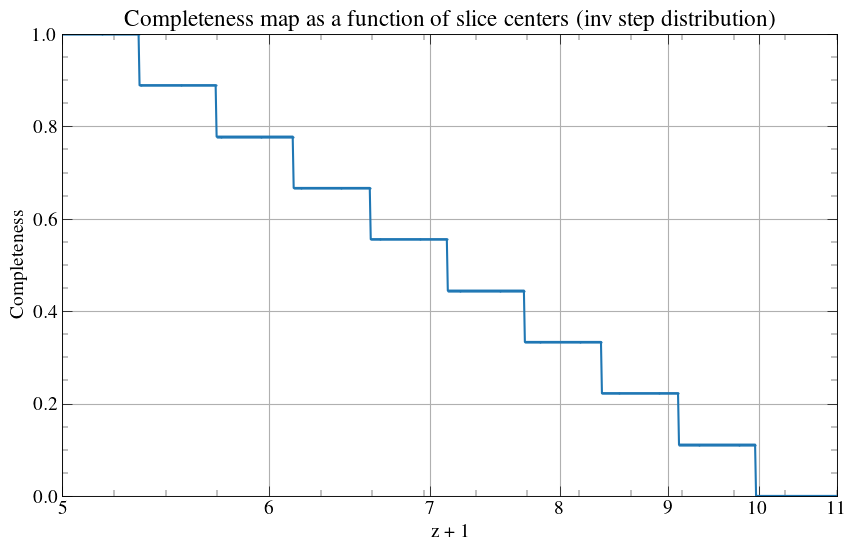

In [11]:
# I want to make a completeness map of the light cone constructed. Basically it is a function of z, which gives the fraction of the black holes in the light cone that are detected at a given redshift.
# First we have to bin the z axis into slices of 0.1 h^-1 Mpc, inorder to assign incompleteness to each slice.

import matplotlib.pyplot as plt
from astropy.cosmology import z_at_value
from astropy import units as u
import numpy as np
from astropy.cosmology import FlatLambdaCDM

# Set the default font size
plt.rcParams['font.size'] = 14

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
# Define h
h = 0.7

# Define the redshifts
redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

# Define the number of pixels in each dimension
num_pixels_x = 50
num_pixels_y = 50
num_pixels_z = 50

# Calculate the comoving distances
new_z_axis = cosmo.comoving_distance(redshifts).value * h  # Convert to h^-1 Mpc

# Calculate the pixel size in each dimension in Mpch^-1
x_range = (0, 100) #(np.min(x_coordinates), np.max(x_coordinates))
y_range = (0, 100) #(np.min(y_coordinates), np.max(y_coordinates))
z_range = (0, 100) #(np.min(z_coordinates), np.max(z_coordinates))

pixel_size_x = (x_range[1] - x_range[0]) / num_pixels_x
pixel_size_y = (y_range[1] - y_range[0]) / num_pixels_y
pixel_size_z = (z_range[1] - z_range[0]) / num_pixels_z

# Now I want to make another 3d array which contains the n(x, y, z) for each comoving distance in the range of new_z_axis.
# Define the new z axis which has the resolution of the simulation box.

new_z_axis = np.arange(new_z_axis[0], new_z_axis[-1], pixel_size_z)

# Calculate the number of slices
num_slices = len(new_z_axis)

# Now let's make another completeness map. I want the completenss map to look like a step function with multiple steps. We already have slice_centers which is the center of the slices.

# Define the number of steps
num_steps = 10

# Calculate the completeness map as a step function with multiple steps
completeness_map_steps = np.zeros(num_slices)
step_size = num_slices // num_steps

for i in range(num_steps):
    completeness_map_steps[i * step_size:(i + 1) * step_size] = (num_steps - i - 1) / (num_steps - 1)

completeness_map = completeness_map_steps

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the completeness map as a function of the slice centers
ax1.plot(new_z_axis, completeness_map, marker='.', linestyle='-', markersize=1)

# Make a second axis on top of the plot to show the redshifts corresponding to the z coordinates. I need the same number of ticks as the first axis but the 
# tick labels should be the redshifts corresponding to the z coordinates.
# ax2 = ax1.twiny()
# ax2.set_xlabel('Redshift', fontsize=16)

# # Get the limits of the ax1 axis
# ax1_xlims = ax1.get_xlim()

# # Set the limits of the ax2 axis to be the same as the ax1 axis
# ax2.set_xlim(ax1_xlims)

# # Extract the current xtick labels
# xticks = ax1.get_xticks()
# # Convert the xticks to redshifts just in numbers
# redshifts = [np.round(z_at_value(cosmo.comoving_distance, dist / h * u.Mpc).value,2) for dist in xticks]
# # Set the xticks and labels for the top axis
# ax2.set_xticks(xticks[1:-1])
# ax2.set_xticklabels(redshifts[1:-1], fontsize=14)

ax1.set_xlabel(r'Slice center ($h^-1 Mpc$)')
ax1.set_ylabel('Completeness')
plt.title('Completeness map as a function of slice centers (inv step distribution)')
plt.grid(True)
# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h # Convert to h^-1 Mpc

# remove the xticks and xticklabels
ax1.set_xticks([])

# Now add the redcom values as xticks
ax1.set_xticks(red_com, redshifts + 1)
ax1.set_xlabel('z + 1')
plt.show()

# I want to save the completeness map to a file for later use. I will save the slice centers and the completeness values to a CSV file.
# Save the completeness map to a CSV file
completeness_data = np.column_stack((new_z_axis, completeness_map))
np.savetxt(DATA_DIRECTORY + 'completeness_map_steps.csv', completeness_data, delimiter=',', header='Slice center (h^-1 Mpc), Completeness', comments='')

Number of selected black holes: 8260
10000
8260


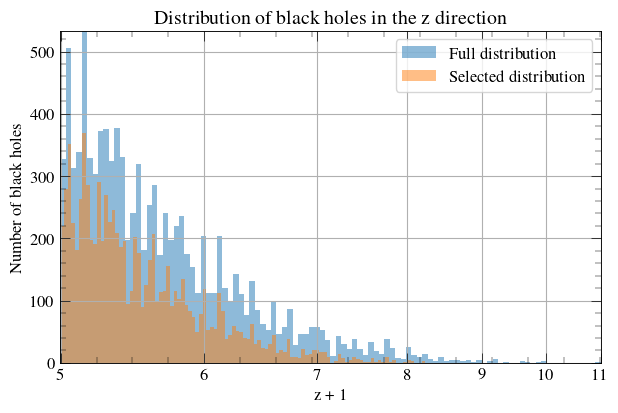

done


In [36]:
# The idea is to automate the process of calculating the correlation function for the full and selected black holes given the 
# completeness map. This code takes the completeness map as input and calculates the correlation function for the full and selected
# black holes and outputs the calculated correlaion function .csv files.  

import matplotlib.pyplot as plt
from astropy.cosmology import z_at_value
from astropy import units as u
import numpy as np
from astropy.cosmology import FlatLambdaCDM

# Set the matplotlib style
plt.style.use('MNRAS_Style.mplstyle')

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
# Define h
h = 0.7

# Completenss map is basically the number of black holes that are selected from the given slice out of the total black holes in the slice.
# x_coords, y_coords, z_coords are the coordinates of the black holes in the light cone constructed.
# I want to find the slice to which each black hole belongs and choose randomly a fraction of black holes from each slice according to the completeness map.

# Import the kernel density estimation function from scikit-learn
from sklearn.neighbors import KernelDensity
# Import the DD function from Corrfunc
from Corrfunc.theory.DD import DD

# Read the completeness map from the file
completeness_data = np.loadtxt(DATA_DIRECTORY + 'completeness_map_steps.csv', delimiter=',', skiprows=1)
slice_centers = completeness_data[:, 0]
completeness_map = completeness_data[:, 1]

# Import the black hole coordinates from the file
bh_coordinates = np.load(DATA_DIRECTORY + 'bh_coordinates_lightcone_v3.npy')

# Define the number of black holes to choose for the subset
num_black_holes = 10000

# randomly draw num_black_holes from the bh_coordinates
if num_black_holes > bh_coordinates.shape[0]:
    num_black_holes = bh_coordinates.shape[0]
random_indices = np.random.choice(bh_coordinates.shape[0], num_black_holes, replace=False)
random_bh_coordinates = bh_coordinates[random_indices]

# Get the z coordinates of the black holes
z_coords = random_bh_coordinates[:, 2]

# Get the x and y coordinates of the black holes
x_coords = random_bh_coordinates[:, 0]
y_coords = random_bh_coordinates[:, 1]

# Define the subset of black holes to use for the correlation function
bh_pos_x = x_coords
bh_pos_y = y_coords
bh_pos_z = z_coords

# Define the redshifts
redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

# Define the number of pixels in each dimension
num_pixels_x = 50
num_pixels_y = 50
num_pixels_z = 50

# Calculate the comoving distances
new_z_axis = cosmo.comoving_distance(redshifts).value * h  # Convert to h^-1 Mpc

# Calculate the pixel size in each dimension in Mpch^-1
x_range = (0, 100) #(np.min(x_coordinates), np.max(x_coordinates))
y_range = (0, 100) #(np.min(y_coordinates), np.max(y_coordinates))
z_range = (0, 100) #(np.min(z_coordinates), np.max(z_coordinates))

pixel_size_x = (x_range[1] - x_range[0]) / num_pixels_x
pixel_size_y = (y_range[1] - y_range[0]) / num_pixels_y
pixel_size_z = (z_range[1] - z_range[0]) / num_pixels_z

# Now I want to make another 3d array which contains the n(x, y, z) for each comoving distance in the range of new_z_axis.
# Define the new z axis which has the resolution of the simulation box.

new_z_axis = np.arange(new_z_axis[0], new_z_axis[-1], pixel_size_z)

# Calculate the number of slices
num_slices = len(new_z_axis)

# Calculate the z coordinates of the slices
slice_z_coords = new_z_axis

# Calculate the center of the slices
slice_centers = (slice_z_coords[:-1] + slice_z_coords[1:]) / 2

# Assign each black hole to a slice based on its z coordinate
slice_indices = np.digitize(z_coords, slice_z_coords, right=True)

# Choose a fraction of black holes from each slice based on the completeness map
selected_bh_indices = []
for i in range(1, num_slices + 1):
    slice_bh_indices = np.where(slice_indices == i)[0]
    num_bh_in_slice = len(slice_bh_indices)
    num_selected_bh = int(completeness_map[i - 1] * num_bh_in_slice)
    selected_slice_bh_indices = np.random.choice(slice_bh_indices, num_selected_bh, replace=False)
    selected_bh_indices.extend(selected_slice_bh_indices)

# Get the selected black hole coordinates
selected_bh_coordinates = random_bh_coordinates[selected_bh_indices]

# Get the z coordinates of the selected black holes
selected_z_coords = selected_bh_coordinates[:, 2]

# Get the x and y coordinates of the selected black holes
selected_x_coords = selected_bh_coordinates[:, 0]
selected_y_coords = selected_bh_coordinates[:, 1]

# Print the number of selected black holes
print(f'Number of selected black holes: {len(selected_bh_coordinates)}')

# Now I want to plot the distribution of the selected black holes in z direction and compare it with the full distribution.
print(len(z_coords))
print(len(selected_z_coords))
# Create a histogram of the z coordinates of the selected black holes
# plt.figure(figsize=(12, 8))
plt.hist(z_coords, bins=100, alpha=0.5, label='Full distribution')
plt.hist(selected_z_coords, bins=100, alpha=0.5, label='Selected distribution')
# plt.xlabel(r'Z coordinate ($h^-1 Mpc$)')
plt.ylabel('Number of black holes')
plt.title('Distribution of black holes in the z direction')
plt.legend()
# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h # Convert to h^-1 Mpc

# remove the xticks and xticklabels
plt.xticks([])

# Now add the redcom values as xticks
plt.xticks(red_com, redshifts + 1)
plt.xlabel('z + 1')
plt.grid(True)
# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h # Convert to h^-1 Mpc

# remove the xticks and xticklabels
plt.xticks([])

# Now add the redcom values as xticks
plt.xticks(red_com, redshifts + 1)
plt.xlabel('z + 1')
plt.show()

print("done")

# Now I want to calculate the correlation function using the selected black holes and compare it with the correlation function using all black holes.
# Full balck holes correlation function.

min_x = 0
max_x = 100 # h^-1 Mpc. Here x_coords, y_coords, z_coords are in h^-1 Mpc unlike the black holes coordinates directly from the MBII data.
min_y = 0
max_y = 100

mult = 5 ## Number of random points used as a multiple of number of data points
z_bin_size = 0.005   ## Bin size used to produce a new z distribution of the random numbers
bin_size_ar = [0.5]  ## Bin size used for correlation function measurement

for bin_size in bin_size_ar:

    n_D = len(bh_pos_x)
    n_rand = mult * n_D
    rand_x = np.random.uniform(min_x, max_x, n_rand)
    rand_y = np.random.uniform(min_y, max_y, n_rand)

    #-------------------------------------------------------------------------------------------
    #Drawing random numbers for z from smoothed distribution of the data z vals

    z_bin = np.arange(np.min(bh_pos_z), np.max(bh_pos_z), z_bin_size)[:,np.newaxis]
    z_bin_mid = (z_bin + z_bin_size/2)[:-1]
    kde = KernelDensity(kernel="gaussian", bandwidth=50).fit(bh_pos_z[:,np.newaxis])
    log_dens = kde.score_samples(z_bin_mid)
    pdf = np.exp(log_dens)
    # ax.fill(pos_z[:, 0], pdf, fc="#AAAAFF")
    cdf = np.cumsum(pdf)
    cdf = cdf / np.max(cdf)
    cdf = np.insert(cdf, 0, 0)

    z_bin = z_bin.flatten()
    z_bin_mid = z_bin_mid.flatten()

    uni_val = np.random.rand(n_rand)
    bin_indices = np.searchsorted(cdf, uni_val)
    bin_edges = z_bin[bin_indices - 1]
    bin_diff = z_bin[bin_indices] - z_bin[bin_indices-1]
    bin_weights = (uni_val - cdf[bin_indices-1]) / (cdf[bin_indices] - cdf[bin_indices-1])
    rand_z = bin_edges + bin_weights * bin_diff

    ## ---------------------------------------------------------------------------------------------------------------------------------------------------

    bins = np.logspace(start=np.log10(1.9868), stop=np.log10(314.915), num=23) #np.arange(0.01, 100, bin_size)
    bin_mids = (bins[0:-1] + bins[1:])/2

    result_DD = DD(autocorr=1, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, periodic=False)
    result_RR = DD(autocorr=1, nthreads=1, binfile=bins, X1 = rand_x, Y1 = rand_y, Z1 = rand_z, periodic=False)
    result_DR = DD(autocorr=0, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, X2 = rand_x, Y2 = rand_y, Z2 = rand_z, periodic=False)

    DD_norm = (n_D * (n_D - 1))/2
    RR_norm = (n_rand * (n_rand - 1))/2
    DR_norm = n_D * n_rand

    DD_count = result_DD['npairs']/2
    RR_count = result_RR['npairs']/2
    DR_count = result_DR['npairs']

    LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)

    pois_err = (1 + LandSzal2pcf)/np.sqrt(np.minimum(DD_count, n_D))

from pandas import DataFrame

df = DataFrame({"r min":bins[0:-1], "r max":bins[1:], "DD count":DD_count, "DR count":DR_count, "RR count": RR_count, "Landy Szalay":LandSzal2pcf, "Pois Error":pois_err})

#Save the data to a file
df.to_csv(DATA_DIRECTORY + 'MBIILightCone_v3_Corrfunc10k_binShen_steps.csv', index=False)

# Selected black holes correlation function.

bh_pos_x = selected_x_coords
bh_pos_y = selected_y_coords
bh_pos_z = selected_z_coords

min_x = 0
max_x = 100 # h^-1 Mpc. Here x_coords, y_coords, z_coords are in h^-1 Mpc unlike the black holes coordinates directly from the MBII data.
min_y = 0
max_y = 100

mult = 10 ## Number of random points used as a multiple of number of data points
z_bin_size = 0.005   ## Bin size used to produce a new z distribution of the random numbers
bin_size_ar = [0.5]  ## Bin size used for correlation function measurement

for bin_size in bin_size_ar:

    n_D = len(bh_pos_x)
    n_rand = mult * n_D
    rand_x = np.random.uniform(min_x, max_x, n_rand)
    rand_y = np.random.uniform(min_y, max_y, n_rand)

    #-------------------------------------------------------------------------------------------
    #Drawing random numbers for z from smoothed distribution of the data z vals

    z_bin = np.arange(np.min(bh_pos_z), np.max(bh_pos_z), z_bin_size)[:,np.newaxis]
    z_bin_mid = (z_bin + z_bin_size/2)[:-1]
    kde = KernelDensity(kernel="gaussian", bandwidth=50).fit(bh_pos_z[:,np.newaxis])
    log_dens = kde.score_samples(z_bin_mid)
    pdf = np.exp(log_dens)
    # ax.fill(pos_z[:, 0], pdf, fc="#AAAAFF")
    cdf = np.cumsum(pdf)
    cdf = cdf / np.max(cdf)
    cdf = np.insert(cdf, 0, 0)

    z_bin = z_bin.flatten()
    z_bin_mid = z_bin_mid.flatten()

    uni_val = np.random.rand(n_rand)
    bin_indices = np.searchsorted(cdf, uni_val)
    bin_edges = z_bin[bin_indices - 1]
    bin_diff = z_bin[bin_indices] - z_bin[bin_indices-1]
    bin_weights = (uni_val - cdf[bin_indices-1]) / (cdf[bin_indices] - cdf[bin_indices-1])
    rand_z = bin_edges + bin_weights * bin_diff

    ## ---------------------------------------------------------------------------------------------------------------------------------------------------

    bins = np.logspace(start=np.log10(1.9868), stop=np.log10(314.915), num=23) #np.arange(0.01, 100, bin_size)
    bin_mids = (bins[0:-1] + bins[1:])/2

    result_DD = DD(autocorr=1, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, periodic=False)
    result_RR = DD(autocorr=1, nthreads=1, binfile=bins, X1 = rand_x, Y1 = rand_y, Z1 = rand_z, periodic=False)
    result_DR = DD(autocorr=0, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, X2 = rand_x, Y2 = rand_y, Z2 = rand_z, periodic=False)

    DD_norm = (n_D * (n_D - 1))/2
    RR_norm = (n_rand * (n_rand - 1))/2
    DR_norm = n_D * n_rand

    DD_count = result_DD['npairs']/2
    RR_count = result_RR['npairs']/2
    DR_count = result_DR['npairs']

    LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)

    pois_err = (1 + LandSzal2pcf)/np.sqrt(np.minimum(DD_count, n_D))

from pandas import DataFrame

df = DataFrame({"r min":bins[0:-1], "r max":bins[1:], "DD count":DD_count, "DR count":DR_count, "RR count": RR_count, "Landy Szalay":LandSzal2pcf, "Pois Error":pois_err})

#Save the data to a file
df.to_csv(DATA_DIRECTORY + 'MBIILightCone_v3_Corrfunc10k_incomp_binShen_steps.csv', index=False)

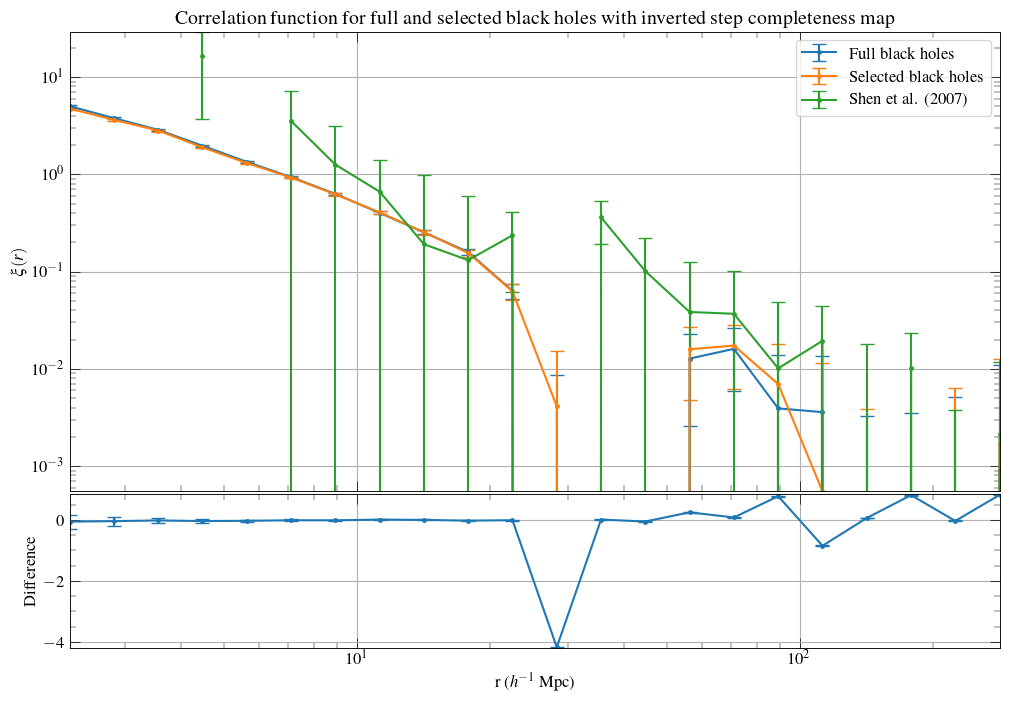

In [3]:
# Let's plot the correlation function for the full and selected black holes.

# import pandas
import pandas as pd
# import numpy ma
import numpy.ma as ma

# matplotlib style
plt.style.use('MNRAS_Style.mplstyle')

# Load the correlation function data
corrfunc_full = pd.read_csv(DATA_DIRECTORY + 'MBIILightCone_v3_Corrfunc10k_binShen_steps.csv')
corrfunc_selected = pd.read_csv(DATA_DIRECTORY + 'MBIILightCone_v3_Corrfunc10k_incomp_binShen_steps.csv')

# Find the midpoint of each bin, as r_mid = (r_min + r_max) / 2
corrfunc_full['r mid'] = (corrfunc_full['r min'] + corrfunc_full['r max']) / 2
corrfunc_selected['r mid'] = (corrfunc_selected['r min'] + corrfunc_selected['r max']) / 2

# Define the Shen et al. (2007) correlation function for comparison
s_bins = np.logspace(start=np.log10(1.9868), stop=np.log10(314.915), num=23)
s_mid = (s_bins[:-1] + s_bins[1:])/2

shen_original = ma.masked_values([0, 0, 0, 16.5, 0, 3.54, 1.26, 0.663, 0.191, 0.131, 0.236, -0.280, 0.361, 0.101, 0.0384, 0.0368, 0.0101, 0.0194, -0.00396, 0.0101, -0.00296, 0.00214], 0)
shen_original_error = ma.masked_values([0, 0, 0, 12.8, 0, 3.61, 1.88, 0.733, 0.786, 0.472, 0.175, 0.223, 0.170, 0.121, 0.0862, 0.0644, 0.0382, \
                                    0.0250, 0.0219, 0.0134, 0.00672, 0.00953], 0)

# Make a subplot on the bottom showing difference between the two correlation functions.

# Plot the correlation function for the full and selected black holes
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax[0].errorbar(corrfunc_full['r mid'], corrfunc_full['Landy Szalay'], yerr=corrfunc_full['Pois Error'], label='Full black holes', fmt='.-', markersize=5, capsize=5)
ax[0].errorbar(corrfunc_selected['r mid'], corrfunc_selected['Landy Szalay'], yerr=corrfunc_selected['Pois Error'], label='Selected black holes', fmt='.-', markersize=5, capsize=5)
ax[0].set_ylabel(r'$\xi(r)$')
ax[0].set_title('Correlation function for full and selected black holes with inverted step completeness map')
ax[0].grid(True)
ax[0].set_xscale('log')
ax[0].set_yscale('log')

# Plot the Shen et al. (2007) correlation function for comparison
ax[0].errorbar(s_mid, shen_original, yerr=shen_original_error, label='Shen et al. (2007)', fmt='.-', markersize=5, capsize=5)

# Calculate the difference between the two correlation functions
diff = (corrfunc_selected['Landy Szalay'] - corrfunc_full['Landy Szalay'])/corrfunc_full['Landy Szalay']
err = np.sqrt(corrfunc_selected['Pois Error']**2 + corrfunc_full['Pois Error']**2)

# Plot the difference between the two correlation functions
ax[1].errorbar(corrfunc_full['r mid'], diff, yerr=err, fmt='.-', markersize=5, capsize=5)
ax[1].set_xlabel(r'r ($h^{-1}$ Mpc)')
ax[1].set_ylabel('Difference')
ax[1].grid(True)
# ax[1].set_xscale('log')

ax[0].legend()

plt.show()

In [48]:
plt.style.use('MNRAS_Style.mplstyle')

#  Make a plot of the number density of the lightcone as a function of redshift.
import numpy as np
import matplotlib.pyplot as plt
# Import interp1d
from scipy.interpolate import interp1d
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM

plt.style.use('MNRAS_Style.mplstyle')

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

file_paths = ['/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_034.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_029.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_026.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_024.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_020.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_019.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_018.txt']

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

# Define the number of pixels in each dimension
num_pixels_x = 50
num_pixels_y = 50
num_pixels_z = 50

# Calculate the pixel size in each dimension in Mpch^-1
x_range = (0, 100) #(np.min(x_coordinates), np.max(x_coordinates))
y_range = (0, 100) #(np.min(y_coordinates), np.max(y_coordinates))
z_range = (0, 100) #(np.min(z_coordinates), np.max(z_coordinates))

pixel_size_x = (x_range[1] - x_range[0]) / num_pixels_x
pixel_size_y = (y_range[1] - y_range[0]) / num_pixels_y
pixel_size_z = (z_range[1] - z_range[0]) / num_pixels_z

BH_density = []

# defining the luminosity bin
min_lum = 0
max_lum = np.infty

# Sum the black hole accretion rate in each simulation box

for file_path in file_paths:
    # Load the data from the file
    data = np.loadtxt(file_path)
    
    # Find the black hole number density
    BH_density.append(len(data[:, 0]))

# Divide by the volume of the simulation box to get the number density
BH_density = np.array(BH_density) / (100**3)

# Remove the h^3 factor from the number density
BH_density = BH_density * h**3

# calculate the volume of one slice z plane of the lightcone
volume = (x_range[1] - x_range[0]) * (y_range[1] - y_range[0]) * pixel_size_z

# Calculate the number density on lightcone
number_density = np.sum(Lightcone, axis=(0, 1)) / volume

# number density is in units of particles per Mpc/h^3. Convert it to particles per Mpc^3
number_density = number_density * h**3

# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h

# Plot the number density as a function of redshift
plt.plot(new_z_axis, number_density, label='Lightcone')
# Plot the BH density as a function of redshift with points
plt.plot(red_com, BH_density, 'o--', label='Simulation Box')

plt.ylabel(r"Number Density $(/cMpc^3)$")
# plt.title('Number Density as a Function of Redshift')
plt.legend()
# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h # Convert to h^-1 Mpc

# remove the xticks and xticklabels
plt.xticks([])

# Now add the redcom values as xticks
plt.xticks(red_com, redshifts + 1)
plt.xlabel('z + 1')
plt.show()


NameError: name 'Lightcone' is not defined

In [45]:
plt.style.use('MNRAS_Style.mplstyle')

#  Make a plot of the number density of the lightcone as a function of redshift.
import numpy as np
import matplotlib.pyplot as plt
# Import interp1d
from scipy.interpolate import interp1d
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM

plt.style.use('MNRAS_Style.mplstyle')

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

file_paths = ['/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_034.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_029.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_026.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_024.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_020.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_019.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_018.txt']

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

BH_lum_density = []

# defining the luminosity bin
min_lum = 0
max_lum = np.infty

# Sum the black hole accretion rate in each simulation box

for file_path in file_paths:
    # Load the data from the file
    data = np.loadtxt(file_path)
    
    # convert the luminosity to solar luminosity
    BH_lum_density.append(np.sum(data[:, 8]) * 1.472 * 10 ** 12)
    

# Divide by the volume of the simulation box to get the luminosity density
BH_lum_density = np.array(BH_lum_density) / (100**3)

# Remove the h^3 factor from the number density
BH_lum_density = BH_lum_density * h**3

# calculate the volume of one slice z plane of the lightcone
volume = (x_range[1] - x_range[0]) * (y_range[1] - y_range[0]) * pixel_size_z

# Calculate the number density on lightcone
lum_density = np.sum(lum_Lightcone, axis=(0, 1)) / volume

# number density is in units of particles per Mpc/h^3. Convert it to particles per Mpc^3
lum_density = lum_density * h**3

# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h

# Plot the number density as a function of redshift
plt.plot(new_z_axis, lum_density, label='Lightcone')
# Plot the BH density as a function of redshift with points
plt.plot(red_com, BH_lum_density, 'o--', label='Simulation Box')

plt.ylabel(r"Luminsoity Density $(L_0/cMpc^3)$")
# plt.title('Number Density as a Function of Redshift')
plt.legend()

# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h # Convert to h^-1 Mpc

# remove the xticks and xticklabels
plt.xticks([])

# Now add the redcom values as xticks
plt.xticks(red_com, redshifts + 1)
plt.xlabel('z + 1')
plt.show()

NameError: name 'x_range' is not defined

# How to reproduce the plot 23 in Khandai et al.

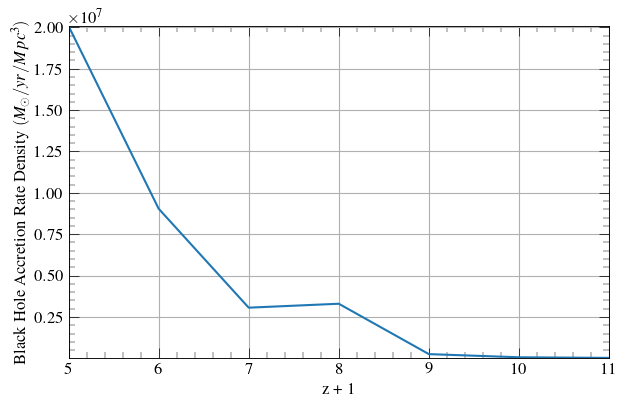

In [28]:
# Code to find the total black hole accretion rate in each simulation box in MBII
import numpy as np
import matplotlib.pyplot as plt
# Import interp1d
from scipy.interpolate import interp1d
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM

plt.style.use('MNRAS_Style.mplstyle')

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

file_paths = ['/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_034.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_029.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_026.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_024.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_020.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_019.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_018.txt']

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

BH_accrate = []

# defining the luminosity bin
min_lum = 0
max_lum = np.infty

# Sum the black hole accretion rate in each simulation box

for file_path in file_paths:
    # Load the data from the file
    data = np.loadtxt(file_path)
    
    # Extract the x, y, and z coordinates
    x_coordinates = data[:, 1]
    y_coordinates = data[:, 2]
    z_coordinates = data[:, 3]
    bh_lum = data[:, 8]

    # Sum the black hole accretion rate in the simulation box
    total_accretion_rate = np.sum(bh_lum)

    # Find the black hole accretion rate solarmass per year
    total_accretion_rate_sol = total_accretion_rate * 1.472 * 10 ** 12 # 1 M0/yr * 0.1 * c^2 equvialent to 1.472 x 10^12 L0

    # find the density of the black hole accretion rate in the simulation box
    # volume of the simulation box
    volume = 100**3 # Mpc^3/h^3

    # Loose the h^3 factor of the volume
    volume = volume / h**3

    total_accretion_rate_density = total_accretion_rate_sol / volume

    #Append the total accretion rate density to the list
    BH_accrate.append(total_accretion_rate_density)

BH_accrate = np.array(BH_accrate)

# Plot the total black hole accretion rate density as a function of redshift + 1
plt.plot(redshifts + 1, BH_accrate)
plt.xlabel('z + 1')
plt.ylabel(r"Black Hole Accretion Rate Density $(M_{\odot}/yr/Mpc^3)$")
# plt.title('Total Black Hole Accretion Rate Density as a Function of Redshift')
plt.show()


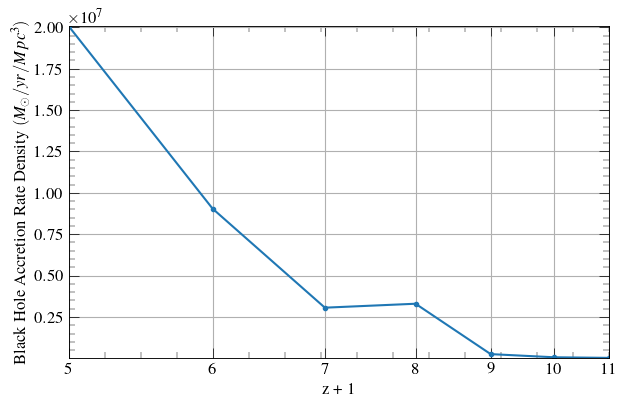

In [32]:
# Code to find the total black hole accretion rate in each simulation box in MBII
import numpy as np
import matplotlib.pyplot as plt
# Import interp1d
from scipy.interpolate import interp1d
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM

plt.style.use('MNRAS_Style.mplstyle')

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

file_paths = ['/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_034.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_029.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_026.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_024.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_020.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_019.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_018.txt']

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

BH_accrate = []

# defining the luminosity bin
min_lum = 0
max_lum = np.infty

# Sum the black hole accretion rate in each simulation box

for file_path in file_paths:
    # Load the data from the file
    data = np.loadtxt(file_path)
    
    # Extract the x, y, and z coordinates
    x_coordinates = data[:, 1]
    y_coordinates = data[:, 2]
    z_coordinates = data[:, 3]
    bh_lum = data[:, 8]

    # Sum the black hole accretion rate in the simulation box
    total_accretion_rate = np.sum(bh_lum)

    # Find the black hole accretion rate solarmass per year
    total_accretion_rate_sol = total_accretion_rate * 1.472 * 10 ** 12 # 1 M0/yr * 0.1 * c^2 equvialent to 1.472 x 10^12 L0

    # find the density of the black hole accretion rate in the simulation box
    # volume of the simulation box
    volume = 100**3 # Mpc^3/h^3

    # Loose the h^3 factor of the volume
    volume = volume / h**3

    total_accretion_rate_density = total_accretion_rate_sol / volume

    #Append the total accretion rate density to the list
    BH_accrate.append(total_accretion_rate_density)

BH_accrate = np.array(BH_accrate)

# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h # Convert to h^-1 Mpc

# Plot the total black hole accretion rate density as a function of redshift + 1
plt.plot(red_com, BH_accrate, '.-')
plt.xlabel('z + 1')
plt.ylabel(r"Black Hole Accretion Rate Density $(M_{\odot}/yr/Mpc^3)$")
# plt.title('Total Black Hole Accretion Rate Density as a Function of Redshift')

# remove the xticks and xticklabels
plt.xticks([])

# Now add the redcom values as xticks
plt.xticks(red_com, redshifts + 1)

plt.show()

In [19]:
# I want to find the two point correlation function in each of the simulation box.
# The idea is to automate the process of calculating the correlation function for the full and selected black holes given the 
# completeness map. This code takes the completeness map as input and calculates the correlation function for the full and selected
# black holes and outputs the calculated correlaion function .csv files.  

# Code to find the total black hole accretion rate in each simulation box in MBII
import numpy as np
import matplotlib.pyplot as plt
# Import interp1d
from scipy.interpolate import interp1d
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM

# Import the kernel density estimation function from scikit-learn
from sklearn.neighbors import KernelDensity
# Import the DD function from Corrfunc
from Corrfunc.theory.DD import DD

plt.style.use('MNRAS_Style.mplstyle')

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"


file_paths = ['/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_034.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_029.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_026.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_024.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_020.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_019.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_018.txt']

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

BH_accrate = []

# defining the luminosity bin
min_lum = 0
max_lum = np.infty

# Sum the black hole accretion rate in each simulation box

for i,file_path in enumerate(file_paths):
    # Load the data from the file
    data = np.loadtxt(file_path)
    
    # Extract the x, y, and z coordinates
    x_coordinates = data[:, 1]
    y_coordinates = data[:, 2]
    z_coordinates = data[:, 3]

    # Define the number of black holes to choose for the subset
    num_black_holes = 10000

    # randomly draw num_black_holes from the bh_coordinates
    if num_black_holes > x_coordinates.shape[0]:
        num_black_holes = x_coordinates.shape[0]
    random_indices = np.random.choice(x_coordinates.shape[0], num_black_holes, replace=False)

    bh_pos_x = x_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    bh_pos_y = y_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    bh_pos_z = z_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    print(len(bh_pos_x), flush=True)

    # Now I want to calculate the correlation function using the selected black holes and compare it with the correlation function using all black holes.
    # Full balck holes correlation function.

    min_x = 0
    max_x = 100 # h^-1 Mpc. Here x_coords, y_coords, z_coords are in h^-1 Mpc unlike the black holes coordinates directly from the MBII data.
    min_y = 0
    max_y = 100

    mult = 5 ## Number of random points used as a multiple of number of data points
    z_bin_size = 0.005   ## Bin size used to produce a new z distribution of the random numbers
    bin_size_ar = [0.5]  ## Bin size used for correlation function measurement

    for bin_size in bin_size_ar:

        n_D = len(bh_pos_x)
        n_rand = mult * n_D
        rand_x = np.random.uniform(min_x, max_x, n_rand)
        rand_y = np.random.uniform(min_y, max_y, n_rand)

        #-------------------------------------------------------------------------------------------
        #Drawing random numbers for z from smoothed distribution of the data z vals

        z_bin = np.arange(np.min(bh_pos_z), np.max(bh_pos_z), z_bin_size)[:,np.newaxis]
        z_bin_mid = (z_bin + z_bin_size/2)[:-1]
        kde = KernelDensity(kernel="gaussian", bandwidth=50).fit(bh_pos_z[:,np.newaxis])
        log_dens = kde.score_samples(z_bin_mid)
        pdf = np.exp(log_dens)
        # ax.fill(pos_z[:, 0], pdf, fc="#AAAAFF")
        cdf = np.cumsum(pdf)
        cdf = cdf / np.max(cdf)
        cdf = np.insert(cdf, 0, 0)

        z_bin = z_bin.flatten()
        z_bin_mid = z_bin_mid.flatten()

        uni_val = np.random.rand(n_rand)
        bin_indices = np.searchsorted(cdf, uni_val)
        bin_edges = z_bin[bin_indices - 1]
        bin_diff = z_bin[bin_indices] - z_bin[bin_indices-1]
        bin_weights = (uni_val - cdf[bin_indices-1]) / (cdf[bin_indices] - cdf[bin_indices-1])
        rand_z = bin_edges + bin_weights * bin_diff

        ## ---------------------------------------------------------------------------------------------------------------------------------------------------

        bins = np.logspace(start=np.log10(1.9868), stop=np.log10(314.915), num=23) #np.arange(0.01, 100, bin_size)
        bin_mids = (bins[0:-1] + bins[1:])/2

        result_DD = DD(autocorr=1, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, periodic=False)
        result_RR = DD(autocorr=1, nthreads=1, binfile=bins, X1 = rand_x, Y1 = rand_y, Z1 = rand_z, periodic=False)
        result_DR = DD(autocorr=0, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, X2 = rand_x, Y2 = rand_y, Z2 = rand_z, periodic=False)

        DD_norm = (n_D * (n_D - 1))/2
        RR_norm = (n_rand * (n_rand - 1))/2
        DR_norm = n_D * n_rand

        DD_count = result_DD['npairs']/2
        RR_count = result_RR['npairs']/2
        DR_count = result_DR['npairs']

        LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)

        pois_err = (1 + LandSzal2pcf)/np.sqrt(np.minimum(DD_count, n_D))

        # where pois_err is negative and infinity, replace it with 0
        pois_err[pois_err < 0] = np.NAN
        pois_err[pois_err == np.inf] = np.NAN


    from pandas import DataFrame

    df = DataFrame({"r min":bins[0:-1], "r max":bins[1:], "DD count":DD_count, "DR count":DR_count, "RR count": RR_count, "Landy Szalay":LandSzal2pcf, "Pois Error":pois_err})

    #Save the data to a file
    df.to_csv(DATA_DIRECTORY + 'MBII_corrfunc_z{}.csv'.format(redshifts[i]), index=False)
    print("done with redshift {}".format(redshifts[i]), flush=True)

10000


done with redshift 4
8036


/tmp/ipykernel_70778/1940855527.py:130: RuntimeWarning: invalid value encountered in divide
  LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)


done with redshift 5
2771


/tmp/ipykernel_70778/1940855527.py:130: RuntimeWarning: invalid value encountered in divide
  LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)


...

/tmp/ipykernel_70778/1940855527.py:130: RuntimeWarning: invalid value encountered in divide
  LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)
/tmp/ipykernel_70778/1940855527.py:132: RuntimeWarning: divide by zero encountered in divide
  pois_err = (1 + LandSzal2pcf)/np.sqrt(np.minimum(DD_count, n_D))


done with redshift 9
18


/tmp/ipykernel_70778/1940855527.py:130: RuntimeWarning: divide by zero encountered in divide
  LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)
/tmp/ipykernel_70778/1940855527.py:130: RuntimeWarning: invalid value encountered in divide
  LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)


done with redshift 10


/tmp/ipykernel_70778/1940855527.py:130: RuntimeWarning: divide by zero encountered in divide
  LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)
/tmp/ipykernel_70778/1940855527.py:130: RuntimeWarning: invalid value encountered in divide
  LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)
/tmp/ipykernel_70778/1940855527.py:132: RuntimeWarning: divide by zero encountered in divide
  pois_err = (1 + LandSzal2pcf)/np.sqrt(np.minimum(DD_count, n_D))


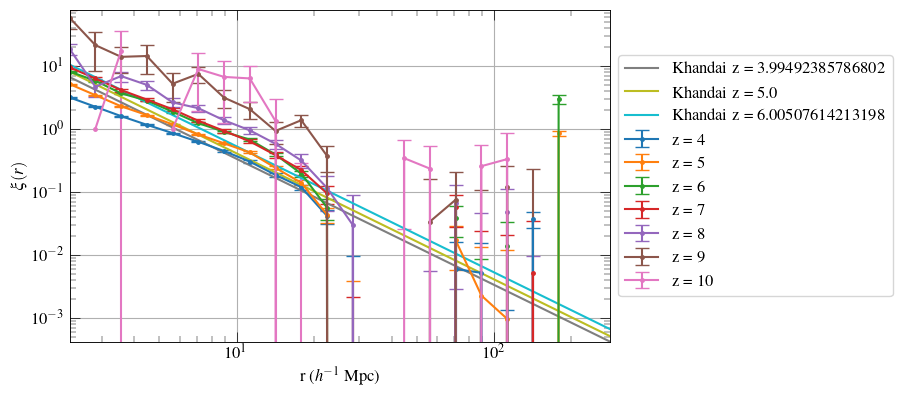

In [44]:
# plot the correlation function from MBII_corrfunc_z{}.csv files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('MNRAS_Style.mplstyle')

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Define the redshifts
redshifts = np.array([4, 5, 6, 7, 8, 9, 10])


# Load the correlation function data
corrfunc_data = []
for i in redshifts:
    corrfunc_data.append(pd.read_csv(DATA_DIRECTORY + 'MBII_corrfunc_z{}.csv'.format(i)))

# Find the midpoint of each bin, as r_mid = (r_min + r_max) / 2
for i in range(len(redshifts)):
    corrfunc_data[i]['r mid'] = (corrfunc_data[i]['r min'] + corrfunc_data[i]['r max']) / 2

# Plot all the correlation functions
for i in range(len(redshifts)):
    plt.errorbar(corrfunc_data[i]['r mid'], corrfunc_data[i]['Landy Szalay'], yerr=corrfunc_data[i]['Pois Error'], label='z = {}'.format(redshifts[i]), fmt='.-', markersize=5, capsize=5)

plt.ylabel(r'$\xi(r)$')
plt.xlabel(r'r ($h^{-1}$ Mpc)')
plt.legend()
# plt.ylim(-0.5, 10)
# plt.xlim(0, 150)
plt.xscale('log')
plt.yscale('log')

temp_DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/"
temp_rmid = corrfunc_data[0]['r mid']

# Now also plot the correlation function from khandai et al. 2015 as power laws
MBII_fig25_filename = "Khandai_fig25_data.csv"
MBII_fig25 = np.loadtxt(temp_DATA_DIRECTORY + MBII_fig25_filename, skiprows=1, delimiter=',')

MBII_fig25_z = MBII_fig25[:, 0]
MBII_fig25_r0 = MBII_fig25[:, 1]

MBII_gamma = 2.0

for i in range(len(MBII_fig25_z[5:])):
    plt.plot(temp_rmid, (temp_rmid/MBII_fig25_r0[i+5])**(-MBII_gamma), label='Khandai z = {}'.format(MBII_fig25_z[i+5]))

plt.legend()
# give legends outside the plots
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [49]:
# I want to find the two point correlation function in each of the simulation box.
# The idea is to automate the process of calculating the correlation function for the full and selected black holes given the 
# completeness map. This code takes the completeness map as input and calculates the correlation function for the full and selected
# black holes and outputs the calculated correlaion function .csv files.  

# Code to find the total black hole accretion rate in each simulation box in MBII
import numpy as np
import matplotlib.pyplot as plt
# Import interp1d
from scipy.interpolate import interp1d
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM

# Import the kernel density estimation function from scikit-learn
from sklearn.neighbors import KernelDensity
# Import the DD function from Corrfunc
from Corrfunc.theory.DD import DD

plt.style.use('MNRAS_Style.mplstyle')

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"


file_paths = ['/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_034.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_029.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_026.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_024.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_020.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_019.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_018.txt']

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

BH_accrate = []

# defining the luminosity bin
min_lum = 0
max_lum = np.infty

# Sum the black hole accretion rate in each simulation box

for i,file_path in enumerate(file_paths):
    # Load the data from the file
    data = np.loadtxt(file_path)
    
    # Extract the x, y, and z coordinates
    x_coordinates = data[:, 1]
    y_coordinates = data[:, 2]
    z_coordinates = data[:, 3]

    # Define the number of black holes to choose for the subset
    num_black_holes = 10000

    # randomly draw num_black_holes from the bh_coordinates
    if num_black_holes > x_coordinates.shape[0]:
        num_black_holes = x_coordinates.shape[0]
    random_indices = np.random.choice(x_coordinates.shape[0], num_black_holes, replace=False)

    bh_pos_x = x_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    bh_pos_y = y_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    bh_pos_z = z_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    print(len(bh_pos_x), flush=True)

    # Now I want to calculate the correlation function using the selected black holes and compare it with the correlation function using all black holes.
    # Full balck holes correlation function.

    min_x = 0
    max_x = 100 # h^-1 Mpc. Here x_coords, y_coords, z_coords are in h^-1 Mpc unlike the black holes coordinates directly from the MBII data.
    min_y = 0
    max_y = 100

    mult = 5 ## Number of random points used as a multiple of number of data points
    z_bin_size = 0.005   ## Bin size used to produce a new z distribution of the random numbers
    bin_size_ar = [0.5]  ## Bin size used for correlation function measurement

    for bin_size in bin_size_ar:

        n_D = len(bh_pos_x)
        n_rand = mult * n_D
        rand_x = np.random.uniform(min_x, max_x, n_rand)
        rand_y = np.random.uniform(min_y, max_y, n_rand)

        #-------------------------------------------------------------------------------------------
        #Drawing random numbers for z from smoothed distribution of the data z vals

        z_bin = np.arange(np.min(bh_pos_z), np.max(bh_pos_z), z_bin_size)[:,np.newaxis]
        z_bin_mid = (z_bin + z_bin_size/2)[:-1]
        kde = KernelDensity(kernel="gaussian", bandwidth=50).fit(bh_pos_z[:,np.newaxis])
        log_dens = kde.score_samples(z_bin_mid)
        pdf = np.exp(log_dens)
        # ax.fill(pos_z[:, 0], pdf, fc="#AAAAFF")
        cdf = np.cumsum(pdf)
        cdf = cdf / np.max(cdf)
        cdf = np.insert(cdf, 0, 0)

        z_bin = z_bin.flatten()
        z_bin_mid = z_bin_mid.flatten()

        uni_val = np.random.rand(n_rand)
        bin_indices = np.searchsorted(cdf, uni_val)
        bin_edges = z_bin[bin_indices - 1]
        bin_diff = z_bin[bin_indices] - z_bin[bin_indices-1]
        bin_weights = (uni_val - cdf[bin_indices-1]) / (cdf[bin_indices] - cdf[bin_indices-1])
        rand_z = bin_edges + bin_weights * bin_diff

        ## ---------------------------------------------------------------------------------------------------------------------------------------------------

        bins = np.logspace(start=np.log10(1.9868), stop=np.log10(314.915), num=23) #np.arange(0.01, 100, bin_size)
        bin_mids = (bins[0:-1] + bins[1:])/2

        result_DD = DD(autocorr=1, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, periodic=False)
        result_RR = DD(autocorr=1, nthreads=1, binfile=bins, X1 = rand_x, Y1 = rand_y, Z1 = rand_z, periodic=False)
        result_DR = DD(autocorr=0, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, X2 = rand_x, Y2 = rand_y, Z2 = rand_z, periodic=False)

        DD_norm = (n_D * (n_D - 1))/2
        RR_norm = (n_rand * (n_rand - 1))/2
        DR_norm = n_D * n_rand

        DD_count = result_DD['npairs']/2
        RR_count = result_RR['npairs']/2
        DR_count = result_DR['npairs']

        LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)

        pois_err = (1 + LandSzal2pcf)/np.sqrt(np.minimum(DD_count, n_D))

        # where pois_err is negative and infinity, replace it with 0
        pois_err[pois_err < 0] = np.NAN
        pois_err[pois_err == np.inf] = np.NAN


    from pandas import DataFrame

    df = DataFrame({"r min":bins[0:-1], "r max":bins[1:], "DD count":DD_count, "DR count":DR_count, "RR count": RR_count, "Landy Szalay":LandSzal2pcf, "Pois Error":pois_err})

    #Save the data to a file
    df.to_csv(DATA_DIRECTORY + 'MBII_corrfunc_z{}.csv'.format(redshifts[i]), index=False)
    print("done with redshift {}".format(redshifts[i]), flush=True)
    break

10000
done with redshift 4


/tmp/ipykernel_70778/309493312.py:130: RuntimeWarning: invalid value encountered in divide
  LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)


Text(0.5, 0, 'r ($h^{-1}$ Mpc)')

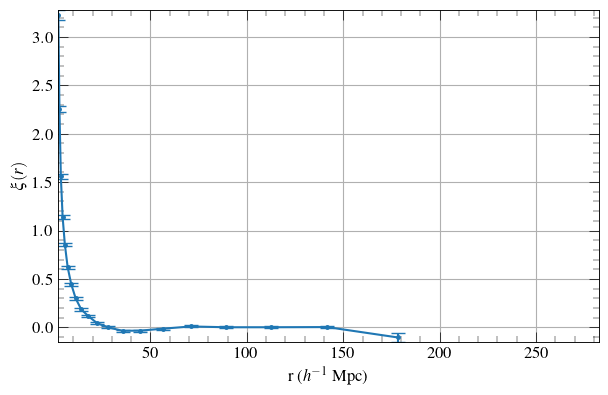

In [2]:
# plot the correlation function from MBII_corrfunc_z{}.csv files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('MNRAS_Style.mplstyle')

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Define the redshifts
redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

# Load the correlation function data only for z = 4
corrfunc_data = pd.read_csv(DATA_DIRECTORY + 'MBII_corrfunc_z{}.csv'.format(4))

# find the midpoint of each bin, as r_mid = (r_min + r_max) / 2
corrfunc_data['r mid'] = (corrfunc_data['r min'] + corrfunc_data['r max']) / 2

# plot this correlation function
plt.errorbar(corrfunc_data['r mid'], corrfunc_data['Landy Szalay'], yerr=corrfunc_data['Pois Error'], fmt='.-', markersize=5, capsize=5)
plt.ylabel(r'$\xi(r)$')
plt.xlabel(r'r ($h^{-1}$ Mpc)')


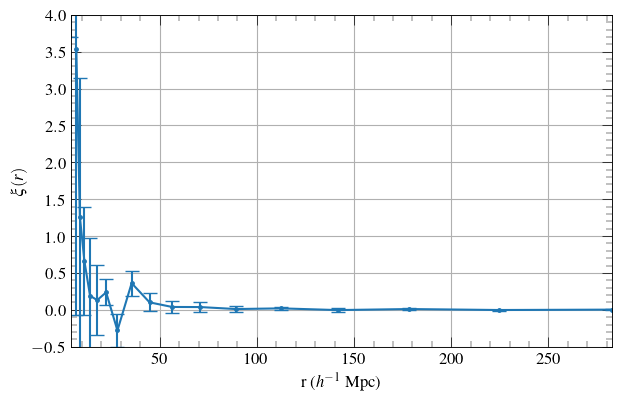

In [7]:
# Define all the libraries and functions
import numpy as np
import matplotlib.pyplot as plt
import numpy.ma as ma


# Define the Shen et al. (2007) correlation function for comparison
s_bins = np.logspace(start=np.log10(1.9868), stop=np.log10(314.915), num=23)
s_mid = (s_bins[:-1] + s_bins[1:])/2

shen_original = ma.masked_values([0, 0, 0, 16.5, 0, 3.54, 1.26, 0.663, 0.191, 0.131, 0.236, -0.280, 0.361, 0.101, 0.0384, 0.0368, 0.0101, 0.0194, -0.00396, 0.0101, -0.00296, 0.00214], 0)
shen_original_error = ma.masked_values([0, 0, 0, 12.8, 0, 3.61, 1.88, 0.733, 0.786, 0.472, 0.175, 0.223, 0.170, 0.121, 0.0862, 0.0644, 0.0382, \
                                    0.0250, 0.0219, 0.0134, 0.00672, 0.00953], 0)

# Plot the Shen et al. (2007) correlation function
plt.errorbar(s_mid, shen_original, yerr=shen_original_error, fmt='.-', markersize=5, capsize=5)
# define the labels
plt.xlabel(r'r ($h^{-1}$ Mpc)')
plt.ylabel(r'$\xi(r)$')
plt.ylim(-0.5, 4)
plt.show()

In [4]:
# I want to find the two point correlation function in each of the simulation box. 

import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM
# Import the DD function from Corrfunc
from Corrfunc.theory.DD import DD

plt.style.use('MNRAS_Style.mplstyle')

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"


file_paths = ['/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_034.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_029.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_026.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_024.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_020.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_019.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_018.txt']

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

for i,file_path in enumerate(file_paths):
    # Load the data from the file
    data = np.loadtxt(file_path)
    
    # Extract the x, y, and z coordinates
    x_coordinates = data[:, 1]
    y_coordinates = data[:, 2]
    z_coordinates = data[:, 3]

    # Define the number of black holes to choose for the subset
    num_black_holes = 10000

    # randomly draw num_black_holes from the bh_coordinates
    if num_black_holes > x_coordinates.shape[0]:
        num_black_holes = x_coordinates.shape[0]
    random_indices = np.random.choice(x_coordinates.shape[0], num_black_holes, replace=False)

    bh_pos_x = x_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    bh_pos_y = y_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    bh_pos_z = z_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    print(len(bh_pos_x), flush=True)

    # Now I want to calculate the correlation function using the selected black holes and compare it with the correlation function using all black holes.
    # Full balck holes correlation function.

    min_x = 0
    max_x = 100 # h^-1 Mpc. Here x_coords, y_coords, z_coords are in h^-1 Mpc unlike the black holes coordinates directly from the MBII data.
    min_y = 0
    max_y = 100
    min_z = 0
    max_z = 100

    mult = 10 ## Number of random points used as a multiple of number of data points

    n_D = len(bh_pos_x)
    n_rand = mult * n_D
    rand_x = np.random.uniform(min_x, max_x, n_rand)
    rand_y = np.random.uniform(min_y, max_y, n_rand)
    rand_z = np.random.uniform(min_z, max_z, n_rand)

    bins = np.logspace(start=np.log10(1.9868), stop=np.log10(314.915), num=23) #np.arange(0.01, 100, bin_size)
    bin_mids = (bins[0:-1] + bins[1:])/2

    result_DD = DD(autocorr=1, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, periodic=False)
    result_RR = DD(autocorr=1, nthreads=1, binfile=bins, X1 = rand_x, Y1 = rand_y, Z1 = rand_z, periodic=False)
    result_DR = DD(autocorr=0, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, X2 = rand_x, Y2 = rand_y, Z2 = rand_z, periodic=False)

    DD_norm = (n_D * (n_D - 1))/2
    RR_norm = (n_rand * (n_rand - 1))/2
    DR_norm = n_D * n_rand

    DD_count = result_DD['npairs']/2
    RR_count = result_RR['npairs']/2
    DR_count = result_DR['npairs']

    nil_pos = np.where(DD_count * RR_count * DR_count == 0)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)

    LandSzal2pcf = ma.array(LandSzal2pcf)
    LandSzal2pcf[nil_pos] = ma.masked

    with np.errstate(divide='ignore', invalid='ignore'):
        pois_err = (1 + LandSzal2pcf)/np.sqrt(np.minimum(DD_count, n_D))

    pois_err = ma.array(pois_err)
    pois_err[nil_pos] = ma.masked

    from pandas import DataFrame

    df = DataFrame({"r min":bins[0:-1], "r max":bins[1:], "DD count":DD_count, "DR count":DR_count, "RR count": RR_count, "Landy Szalay":LandSzal2pcf, "Pois Error":pois_err})

    #Save the data to a file
    df.to_csv(DATA_DIRECTORY + 'MBII_corrfunc_z{}.csv'.format(redshifts[i]), index=False)

10000
8036
2771
1222
289
69
18


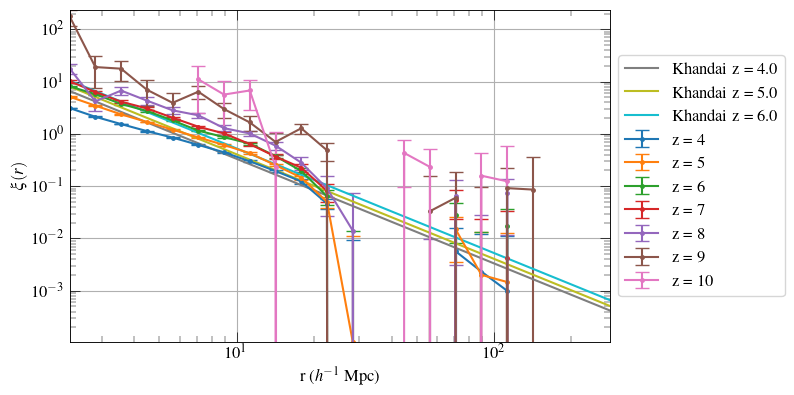

In [2]:
# plot the correlation function from MBII_corrfunc_z{}.csv files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('MNRAS_Style.mplstyle')

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Define the redshifts
redshifts = np.array([4, 5, 6, 7, 8, 9, 10])


# Load the correlation function data
corrfunc_data = []
for i in redshifts:
    corrfunc_data.append(pd.read_csv(DATA_DIRECTORY + 'MBII_corrfunc_z{}.csv'.format(i)))

# Find the midpoint of each bin, as r_mid = (r_min + r_max) / 2
for i in range(len(redshifts)):
    corrfunc_data[i]['r mid'] = (corrfunc_data[i]['r min'] + corrfunc_data[i]['r max']) / 2

# Plot all the correlation functions
for i in range(len(redshifts)):
    plt.errorbar(corrfunc_data[i]['r mid'][:-3], corrfunc_data[i]['Landy Szalay'][:-3], yerr=corrfunc_data[i]['Pois Error'][:-3], label='z = {}'.format(redshifts[i]), fmt='.-', markersize=5, capsize=5)

plt.ylabel(r'$\xi(r)$')
plt.xlabel(r'r ($h^{-1}$ Mpc)')
plt.legend()
# plt.ylim(-0.5, 10)
# plt.xlim(0, 150)
plt.xscale('log')
plt.yscale('log')

temp_DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/"
temp_rmid = corrfunc_data[0]['r mid']

# Now also plot the correlation function from khandai et al. 2015 as power laws
MBII_fig25_filename = "Khandai_fig25_data.csv"
MBII_fig25 = np.loadtxt(temp_DATA_DIRECTORY + MBII_fig25_filename, skiprows=1, delimiter=',')

MBII_fig25_z = MBII_fig25[:, 0]
MBII_fig25_r0 = MBII_fig25[:, 1]

MBII_gamma = 2.0

for i in range(len(MBII_fig25_z[5:])):
    plt.plot(temp_rmid, (temp_rmid/MBII_fig25_r0[i+5])**(-MBII_gamma), label='Khandai z = {}'.format(np.round(MBII_fig25_z[i+5]), 2))

plt.legend()
# give legends outside the plots
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Save the plot as a pdf file
PLOT_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/"

plt.savefig(PLOT_DIRECTORY + 'MBII_corrfunc.pdf')

plt.show()

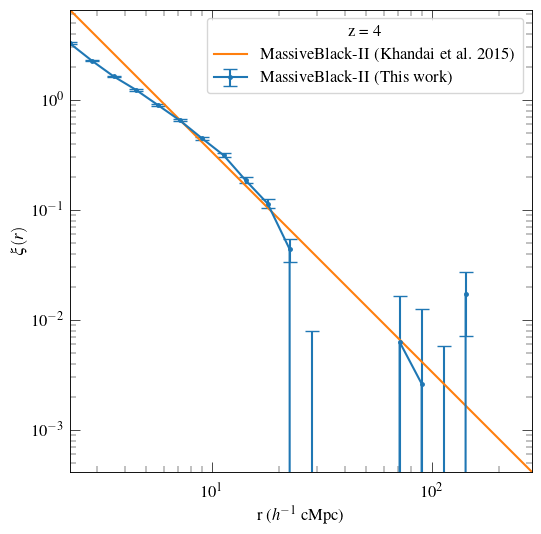

In [9]:
# plot the correlation function from MBII_corrfunc_z{}.csv files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('MNRAS_Style.mplstyle')

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Define the redshifts
redshifts = np.array([4])


# Load the correlation function data
corrfunc_data = []
for i in redshifts:
    corrfunc_data.append(pd.read_csv(DATA_DIRECTORY + 'MBII_corrfunc_z{}.csv'.format(i)))

# Find the midpoint of each bin, as r_mid = (r_min + r_max) / 2
for i in range(len(redshifts)):
    corrfunc_data[i]['r mid'] = (corrfunc_data[i]['r min'] + corrfunc_data[i]['r max']) / 2

plt.figure(figsize=(6, 6))

# Plot all the correlation functions
for i in range(len(redshifts)):
    plt.errorbar(corrfunc_data[i]['r mid'][:-3], corrfunc_data[i]['Landy Szalay'][:-3], yerr=corrfunc_data[i]['Pois Error'][:-3], label='MassiveBlack-II (This work)', fmt='.-', markersize=5, capsize=5)

plt.ylabel(r'$\xi(r)$')
plt.xlabel(r'r ($h^{-1}$ cMpc)')
plt.legend()
# plt.ylim(-0.5, 10)
# plt.xlim(0, 150)
plt.xscale('log')
plt.yscale('log')

temp_DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/"
temp_rmid = corrfunc_data[0]['r mid']

# Now also plot the correlation function from khandai et al. 2015 as power laws
MBII_fig25_filename = "Khandai_fig25_data.csv"
MBII_fig25 = np.loadtxt(temp_DATA_DIRECTORY + MBII_fig25_filename, skiprows=1, delimiter=',')

MBII_fig25_z = MBII_fig25[:, 0]
MBII_fig25_r0 = MBII_fig25[:, 1]

MBII_gamma = 2.0

for i in [0]: #range(len(MBII_fig25_z[5:6])):
    plt.plot(temp_rmid, (temp_rmid/MBII_fig25_r0[i+5])**(-MBII_gamma), label='MassiveBlack-II (Khandai et al. 2015)')

plt.legend(title='z = 4')
plt.grid(visible=False)
# set the box to be square
plt.gca().set_box_aspect(1)

# Adjust the padding for x-axis tick labels
plt.tick_params(axis='x', pad=10)

# give legends outside the plots
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

(0.0, 150.0)

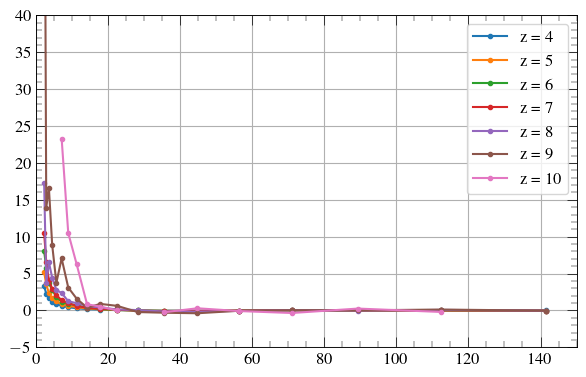

In [19]:
for i in range(len(redshifts)):
    plt.plot(corrfunc_data[i]['r mid'][:-3], corrfunc_data[i]['Landy Szalay'][:-3], '.-', label='z = {}'.format(redshifts[i]))

plt.legend()
plt.ylim(-5, 40)
plt.xlim(0, 150)

In [17]:
corrfunc_data[3]['Landy Szalay'][:-3]

0     10.491965
1      6.552184
2      4.094179
3      2.957969
4      2.044439
5      1.397774
6      0.982822
7      0.627123
8      0.336536
9      0.228408
10     0.100801
11    -0.032771
12    -0.126394
13    -0.098967
14    -0.039043
15     0.054307
16    -0.004065
17     0.004447
18    -0.029727
Name: Landy Szalay, dtype: float64

In [22]:
# I want to find the two point correlation function in each of the simulation box. 

import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM
# Import the DD function from Corrfunc
from Corrfunc.theory.DD import DD

plt.style.use('MNRAS_Style.mplstyle')

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"


file_paths = ['/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_034.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_029.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_026.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_024.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_020.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_019.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_018.txt']

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

for i,file_path in enumerate(file_paths):
    # Load the data from the file
    data = np.loadtxt(file_path)
    
    # Extract the x, y, and z coordinates
    x_coordinates = data[:, 1]
    y_coordinates = data[:, 2]
    z_coordinates = data[:, 3]

    # Define the number of black holes to choose for the subset
    num_black_holes = 10000

    # randomly draw num_black_holes from the bh_coordinates
    if num_black_holes > x_coordinates.shape[0]:
        num_black_holes = x_coordinates.shape[0]
    random_indices = np.random.choice(x_coordinates.shape[0], num_black_holes, replace=False)

    bh_pos_x = x_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    bh_pos_y = y_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    bh_pos_z = z_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    print(len(bh_pos_x), flush=True)

    # Now I want to calculate the correlation function using the selected black holes and compare it with the correlation function using all black holes.
    # Full balck holes correlation function.

    min_x = 0
    max_x = 100 # h^-1 Mpc. Here x_coords, y_coords, z_coords are in h^-1 Mpc unlike the black holes coordinates directly from the MBII data.
    min_y = 0
    max_y = 100
    min_z = 0
    max_z = 100

    mult = 10 ## Number of random points used as a multiple of number of data points

    n_D = len(bh_pos_x)
    n_rand = mult * n_D
    rand_x = np.random.uniform(min_x, max_x, n_rand)
    rand_y = np.random.uniform(min_y, max_y, n_rand)
    rand_z = np.random.uniform(min_z, max_z, n_rand)

    bins =  np.arange(4, 150, 4)
    bin_mids = (bins[0:-1] + bins[1:])/2

    result_DD = DD(autocorr=1, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, periodic=False)
    result_RR = DD(autocorr=1, nthreads=1, binfile=bins, X1 = rand_x, Y1 = rand_y, Z1 = rand_z, periodic=False)
    result_DR = DD(autocorr=0, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, X2 = rand_x, Y2 = rand_y, Z2 = rand_z, periodic=False)

    DD_norm = (n_D * (n_D - 1))/2
    RR_norm = (n_rand * (n_rand - 1))/2
    DR_norm = n_D * n_rand

    DD_count = result_DD['npairs']/2
    RR_count = result_RR['npairs']/2
    DR_count = result_DR['npairs']

    nil_pos = np.where(DD_count * RR_count * DR_count == 0)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)

    LandSzal2pcf = ma.array(LandSzal2pcf)
    LandSzal2pcf[nil_pos] = ma.masked

    with np.errstate(divide='ignore', invalid='ignore'):
        pois_err = (1 + LandSzal2pcf)/np.sqrt(np.minimum(DD_count, n_D))

    pois_err = ma.array(pois_err)
    pois_err[nil_pos] = ma.masked

    from pandas import DataFrame

    df = DataFrame({"r min":bins[0:-1], "r max":bins[1:], "DD count":DD_count, "DR count":DR_count, "RR count": RR_count, "Landy Szalay":LandSzal2pcf, "Pois Error":pois_err})

    #Save the data to a file
    df.to_csv(DATA_DIRECTORY + 'MBII_corrfunc_z_lin{}.csv'.format(redshifts[i]), index=False)

10000
8036
2771
1222
289
69
18


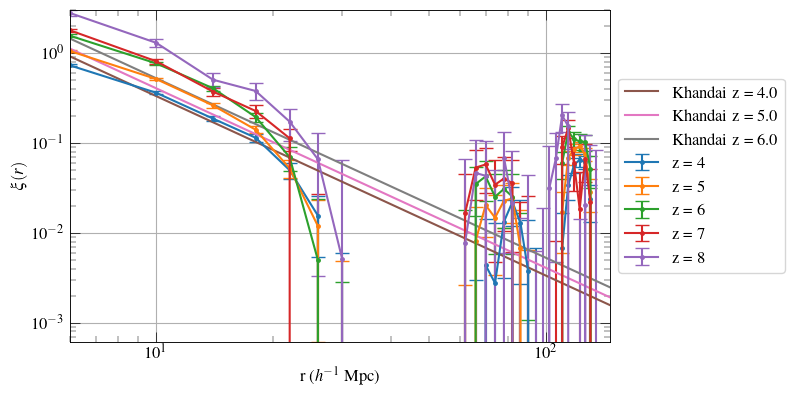

In [25]:
# plot the correlation function from MBII_corrfunc_z{}.csv files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('MNRAS_Style.mplstyle')

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Define the redshifts
redshifts = np.array([4, 5, 6, 7, 8, 9, 10])


# Load the correlation function data
corrfunc_data = []
for i in redshifts:
    corrfunc_data.append(pd.read_csv(DATA_DIRECTORY + 'MBII_corrfunc_z_lin{}.csv'.format(i)))

# Find the midpoint of each bin, as r_mid = (r_min + r_max) / 2
for i in range(len(redshifts)):
    corrfunc_data[i]['r mid'] = (corrfunc_data[i]['r min'] + corrfunc_data[i]['r max']) / 2

# Plot all the correlation functions
for i in range(len(redshifts)-2):
    plt.errorbar(corrfunc_data[i]['r mid'][:-3], corrfunc_data[i]['Landy Szalay'][:-3], yerr=corrfunc_data[i]['Pois Error'][:-3], label='z = {}'.format(redshifts[i]), fmt='.-', markersize=5, capsize=5)

plt.ylabel(r'$\xi(r)$')
plt.xlabel(r'r ($h^{-1}$ Mpc)')
plt.legend()
# plt.ylim(-0.5, 10)
# plt.xlim(0, 150)
plt.xscale('log')
plt.yscale('log')

temp_DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/"
temp_rmid = corrfunc_data[0]['r mid']

# Now also plot the correlation function from khandai et al. 2015 as power laws
MBII_fig25_filename = "Khandai_fig25_data.csv"
MBII_fig25 = np.loadtxt(temp_DATA_DIRECTORY + MBII_fig25_filename, skiprows=1, delimiter=',')

MBII_fig25_z = MBII_fig25[:, 0]
MBII_fig25_r0 = MBII_fig25[:, 1]

MBII_gamma = 2.0

for i in range(len(MBII_fig25_z[5:])):
    plt.plot(temp_rmid, (temp_rmid/MBII_fig25_r0[i+5])**(-MBII_gamma), label='Khandai z = {}'.format(np.round(MBII_fig25_z[i+5]), 2))

plt.legend()
# give legends outside the plots
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()